### For Final Review

#### XGBoost Model

###### CO2_Emission (Âµg/g/day)

In [ ]:
# ==============================
# IBS Project - XGBoost Model (CO2 Emission Prediction)
# ==============================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_csv("Dataset\Soil_microbe_dataset.csv")

# Define target column (second last column = CO2 emission)
target_col = df.columns[-2]

# Split into features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# ------------------------------
# Preprocessing pipelines
# ------------------------------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

# ------------------------------
# Train-test split
# ------------------------------
RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# ------------------------------
# XGBoost Model (Default)
# ------------------------------
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=RANDOM_SEED, verbosity=0))
])

# Train model
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)
print("Model training complete.")

# ------------------------------
# Performance Evaluation
# ------------------------------
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = mean_squared_error(y_test, y_pred_test, squared=False)

print("\nModel Performance on Test Set:")
print(f"R² Score: {test_r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

print("\nTrain vs Test R²:")
print(f"Train: {train_r2:.4f} | Test: {test_r2:.4f}")

<>:17: SyntaxWarning: invalid escape sequence '\S'
<>:17: SyntaxWarning: invalid escape sequence '\S'
C:\Users\RAHUL L S\AppData\Local\Temp\ipykernel_23156\315064781.py:17: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("E:\S3\IBS\Meta-Genomic-Data-Analytics\Final Review\Dataset\Soil_microbe_dataset.csv")


Training XGBoost model...
Model training complete.

Model Performance on Test Set:
R² Score: 0.9996
MAE: 0.0820
RMSE: 0.1032

Train vs Test R²:
Train: 0.9996 | Test: 0.9996


C:\Users\RAHUL L S\anaconda3\envs\EOC\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


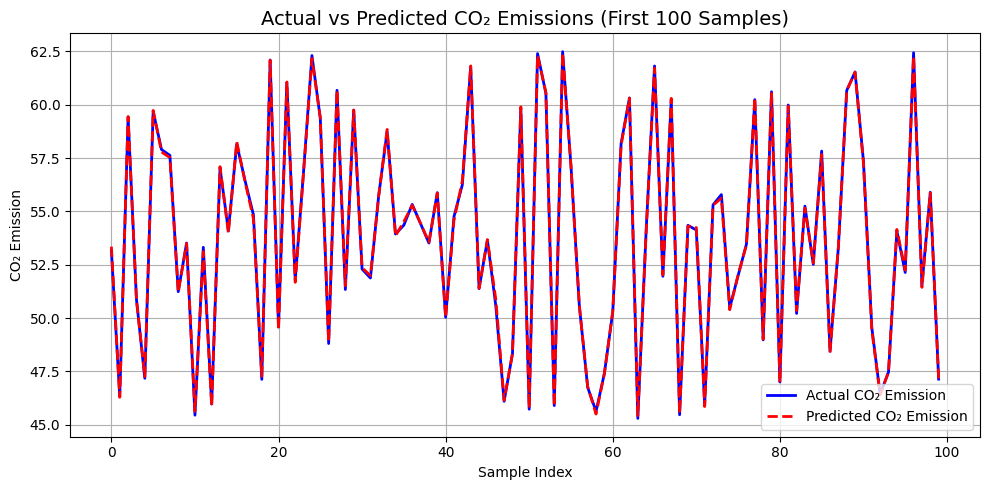

In [2]:
# ------------------------------
# Line Plot: Actual vs Predicted CO2 Emissions
# ------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:100], label='Actual CO₂ Emission', color='blue', linewidth=2)
plt.plot(y_pred_test[:100], label='Predicted CO₂ Emission', color='red', linestyle='--', linewidth=2)
plt.title("Actual vs Predicted CO₂ Emissions (First 100 Samples)", fontsize=14)
plt.xlabel("Sample Index")
plt.ylabel("CO₂ Emission")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()